In [ ]:
# 1. Carga `auto_mpg.csv` y realiza el primer contacto con el dataset. Reporta dimensiones,
# primeras filas, tipos de datos y define qué representa una fila.

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\melvi\Documents\datascience-g8\01-python-intro\data\auto_mpg.csv")
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
5,15.0,8,429.0,198.0,4341,10.0,70,usa,ford galaxie 500
6,14.0,8,454.0,220.0,4354,9.0,70,usa,chevrolet impala
7,14.0,8,440.0,215.0,4312,8.5,70,usa,plymouth fury iii
8,14.0,8,455.0,225.0,4425,10.0,70,usa,pontiac catalina
9,15.0,8,390.0,190.0,3850,8.5,70,usa,amc ambassador dpl


In [6]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB


In [ ]:
# 2. Clasifica `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`,
# `model_year`, `origin` y `name`. Identifica qué variables, aunque puedan verse numéricas,
# conviene tratar como categorías o variables temporales.

clasificacion_variables = pd.DataFrame({
    "Variable": [
        "mpg",
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model_year",
        "origin",
        "name"
    ],
    "Clasificación": [
            "numerica - continua",      
            "categorica - ordinal",     
            "numerica - continua",      
            "numerica - continua",      
            "numerica - continua",      
            "numerica - continua",      
            "categorica - ordinal",     
            "categorica - nominal",     
            "categorica - nominal"
    ]
})

print(clasificacion_variables)

       Variable         Clasificación
0           mpg   numerica - continua
1     cylinders  categorica - ordinal
2  displacement   numerica - continua
3    horsepower   numerica - continua
4        weight   numerica - continua
5  acceleration   numerica - continua
6    model_year  categorica - ordinal
7        origin  categorica - nominal
8          name  categorica - nominal


In [13]:
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

In [ ]:
# 3. Analiza valores faltantes y duplicados exactos. ¿En qué variable faltan datos y qué
# proporción representan?

valores_nulos = pd.DataFrame({
    "numero_nulos": df.isna().sum(),
    "porcentaje": df.isna().mean() * 100
}).sort_values("porcentaje", ascending=False)

valores_nulos


,numero_nulos,porcentaje
horsepower,6,1.507538
mpg,0,0.000000
cylinders,0,0.000000
displacement,0,0.000000
weight,0,0.000000
acceleration,0,0.000000
model_year,0,0.000000
origin,0,0.000000
name,0,0.000000


In [ ]:
# 4. Estudia la cardinalidad de `name`. ¿Cuántos nombres distintos hay? ¿Que un nombre
# aparezca varias veces significa que las filas son duplicadas? Compruébalo con ejemplos.

nombres_distintos = df["name"].nunique()

print("Nombres distintos:", nombres_distintos)

frecuencia_nombres = df["name"].value_counts()
print(frecuencia_nombres[frecuencia_nombres > 1].head(10))

print("Ejemplo")
nombre_ejemplo = frecuencia_nombres[frecuencia_nombres > 1].index[0]

print(nombre_ejemplo)
print(df[df["name"] == nombre_ejemplo])




Nombres distintos: 305
name
ford pinto            6
ford maverick         5
amc matador           5
toyota corolla        5
chevrolet impala      4
amc hornet            4
peugeot 504           4
amc gremlin           4
toyota corona         4
chevrolet chevette    4
Name: count, dtype: int64
Ejemplo
ford pinto
      mpg  cylinders  displacement  horsepower  weight  acceleration  \
32   25.0          4          98.0         NaN    2046          19.0   
112  19.0          4         122.0        85.0    2310          18.5   
130  26.0          4         122.0        80.0    2451          16.5   
168  23.0          4         140.0        83.0    2639          17.0   
174  18.0          6         171.0        97.0    2984          14.5   
206  26.5          4         140.0        72.0    2565          13.6   

     model_year origin        name  
32           71    usa  ford pinto  
112          73    usa  ford pinto  
130          74    usa  ford pinto  
168          75    usa  ford pinto

In [46]:
# 5. Calcula estadísticos descriptivos de `mpg`, `weight` y `horsepower`: media, mediana,
# desviación estándar, cuartiles e IQR. Interpreta qué te dicen sobre un automóvil “típico” y
# sobre la dispersión.

resumen = df[["mpg", "weight", "horsepower"]].agg(["mean", "median", "std"])

q = df[["mpg", "weight", "horsepower"]].quantile([0.25, 0.75]).T
q.columns = ["q1", "q3"]
q["iqr"] = q["q3"] - q["q1"]
q



,q1,q3,iqr
mpg,17.50,29.0,11.50
weight,2223.75,3608.0,1384.25
horsepower,75.00,126.0,51.00


In [105]:
resumen

,mpg,weight,horsepower
mean,23.514573,2970.424623,104.469388
median,23.000000,2803.500000,93.500000
std,7.815984,846.841774,38.491160


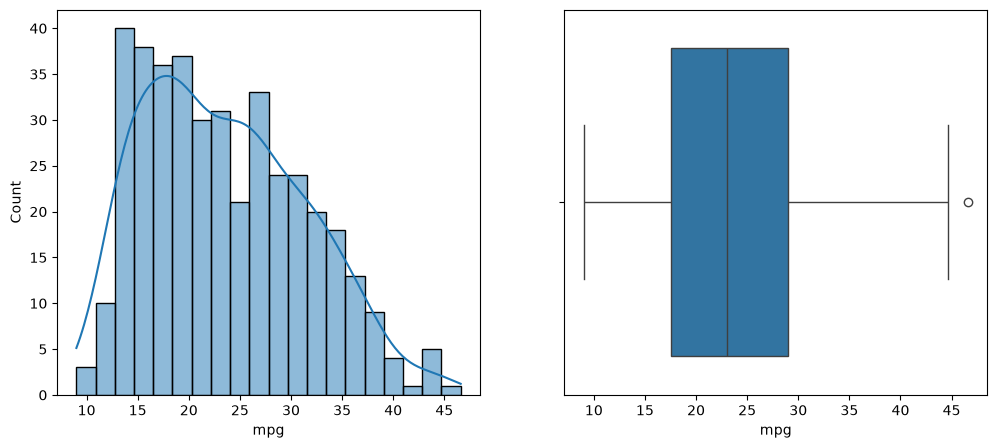

In [20]:
# 6. Analiza la distribución de `mpg` con histograma y KDE.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x="mpg", bins=20, kde=True, ax=axes[0])

sns.boxplot(data=df, x="mpg", ax=axes[1])

plt.show()

weight    147.375
dtype: float64
weight    5684.375
dtype: float64


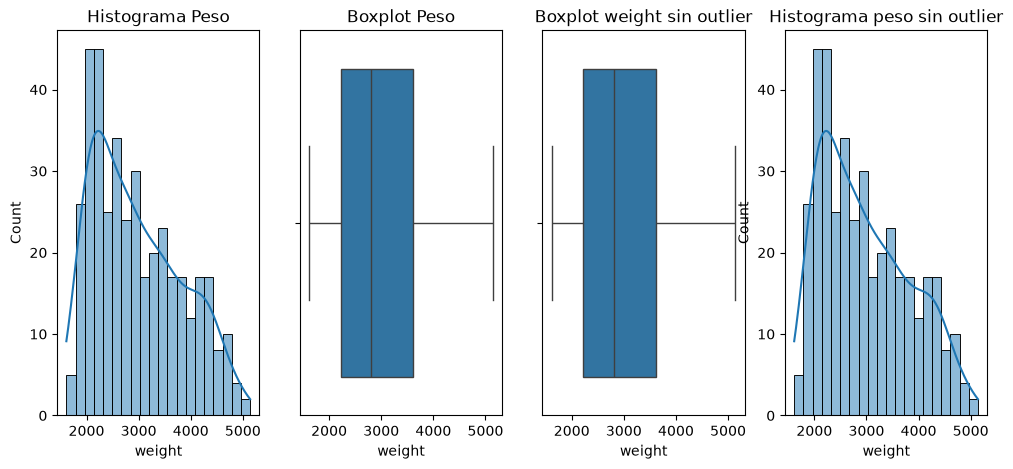

In [95]:
# 7. Analiza `weight` con histograma y boxplot. ¿La distribución es simétrica? ¿Hay valores
# extremos según la regla del IQR? Documenta el cálculo.

fig, axes = plt.subplots(1, 4, figsize=(12, 5))
sns.histplot(data=df, x="weight", bins=20, kde=True, ax=axes[0])
axes[0].set_title("Histograma Peso")

sns.boxplot(data=df, x="weight", ax=axes[1])
axes[1].set_title("Boxplot Peso")

q = df[["weight"]].quantile([0.25, 0.75]).T

q.columns = ["q1", "q3"]
q["iqr"] = q["q3"] - q["q1"]

lower = q["q1"] - 1.5 * q["iqr"]
print(lower)

upper = q["q3"] + 1.5 * q["iqr"]
print(upper)

df_sin_outlier = df[(df["weight"] > lower["weight"]) & (df["weight"] < upper["weight"])]

sns.boxplot(data=df_sin_outlier, x="weight", ax=axes[2])
axes[2].set_title("Boxplot weight sin outlier")

sns.histplot(data=df_sin_outlier, x="weight", bins=20, kde=True, ax=axes[3])
axes[3].set_title("Histograma peso sin outlier")

plt.show()


In [ ]:
# 8. Detecta outliers en `horsepower` usando 1.5·IQR. Lista los vehículos identificados y
# comenta si parecen errores evidentes o automóviles de alta potencia plausibles.

hp = df["horsepower"].dropna()

q1 = hp.quantile(0.25)
q3 = hp.quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers_hp = df[
    df["horsepower"].notna() &
    (
        (df["horsepower"] < limite_inferior) |
        (df["horsepower"] > limite_superior)
    )
]

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

print("Outliers")
print(
    outliers_hp[
        ["horsepower", "mpg", "weight", "model_year", "origin", "name"]
    ].sort_values("horsepower", ascending=False)
)


Q1: 75.0
Q3: 126.0
IQR: 51.0
Límite inferior: -1.5
Límite superior: 202.5
Outliers
     horsepower   mpg  weight  model_year origin                          name
116       230.0  16.0    4278          73    usa            pontiac grand prix
8         225.0  14.0    4425          70    usa              pontiac catalina
95        225.0  12.0    4951          73    usa      buick electra 225 custom
13        225.0  14.0    3086          70    usa       buick estate wagon (sw)
6         220.0  14.0    4354          70    usa              chevrolet impala
7         215.0  14.0    4312          70    usa             plymouth fury iii
94        215.0  13.0    4735          73    usa  chrysler new yorker brougham
25        215.0  10.0    4615          70    usa                     ford f250
27        210.0  11.0    4382          70    usa                    dodge d200
67        208.0  11.0    4633          72    usa               mercury marquis


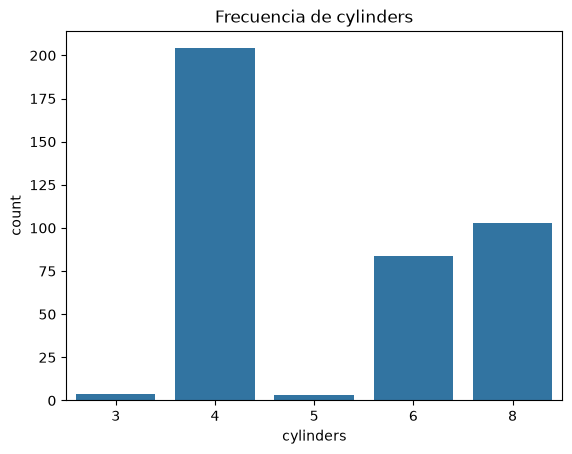

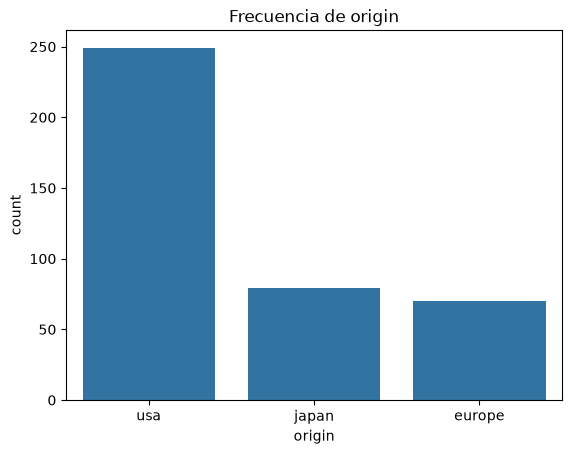

In [ ]:
# 9. Explora `cylinders` y `origin` mediante frecuencias y gráficos de barras. ¿Qué categorías
# dominan el dataset? ¿Hay categorías con muy pocos casos?

for col in ["cylinders", "origin"]:
    sns.countplot(data=df, x=col)
    plt.title(f"Frecuencia de {col}")
    plt.show()

           count       mean  median
cylinders                          
3              4  20.550000   20.25
4            204  29.286765   28.25
5              3  27.366667   25.40
6             84  19.985714   19.00
8            103  14.963107   14.00


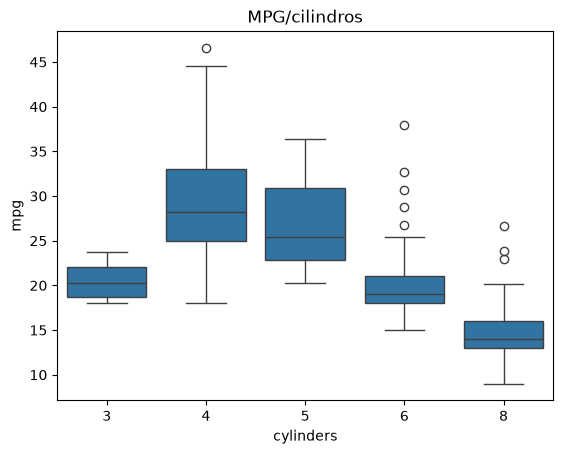

In [98]:
# 10. Compara `mpg` entre vehículos con distinto número de cilindros mediante boxplot y
# medias/medianas por grupo. ¿Qué patrón general observas?

estadisticas = df.groupby("cylinders")["mpg"].agg(
    count="count",
    mean="mean",
    median="median",
)

print(estadisticas)

sns.boxplot(
    data=df,
    x="cylinders",
    y="mpg",
    order=sorted(df["cylinders"].unique())
)

plt.title("MPG/cilindros")
plt.show()

        count       mean  median       std
origin                                    
europe     70  27.891429    26.5  6.723930
japan      79  30.450633    31.6  6.090048
usa       249  20.083534    18.5  6.402892


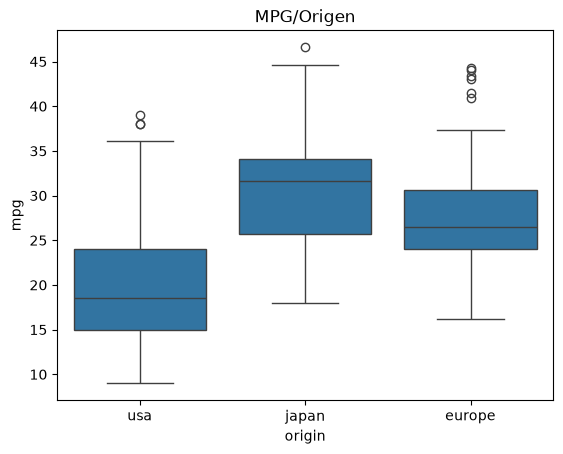

In [ ]:
# 11. Compara `mpg` entre los tres orígenes del dataset. Usa boxplot y estadísticas por grupo.

estadisticas_origin = df.groupby("origin")["mpg"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std"
)

print(estadisticas_origin)

sns.boxplot(
    data=df,
    x="origin",
    y="mpg"
)

plt.title("MPG/Origen")
plt.show()

Correlacion weight/mpg: -0.8317409332443344


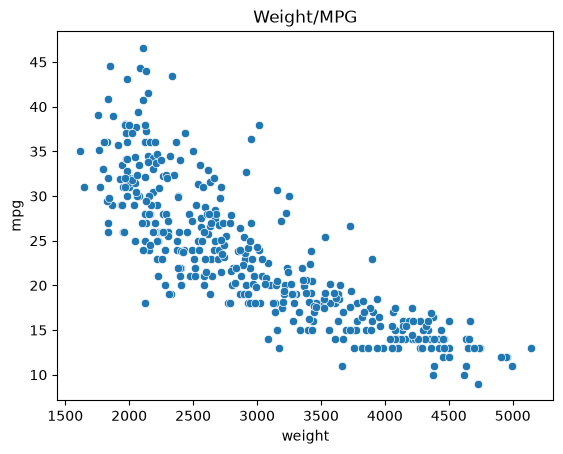

In [52]:
# 12. Estudia la relación entre `weight` y `mpg` con un scatterplot y la correlación.

correlacion_weight_mpg = df[["weight", "mpg"]].corr().loc["weight", "mpg"]

print("Correlacion weight/mpg:", correlacion_weight_mpg)

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg"
)

plt.title("Weight/MPG")
plt.show()

Correlacion horsepower-mpg: -0.7784267838977762
Correlacion weight-mpg: -0.8317409332443344


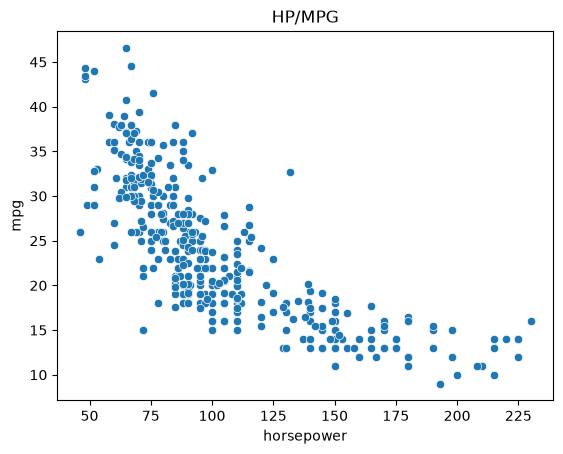

In [ ]:
# 13. Estudia la relación entre `horsepower` y `mpg` con scatterplot y correlación. Compara su
# intensidad con la relación `weight`–`mpg`.

df_hp = df.dropna(subset=["horsepower", "mpg"])

correlacion_hp_mpg = df_hp[["horsepower", "mpg"]].corr().loc[
    "horsepower", "mpg"
]

print("Correlacion horsepower-mpg:", correlacion_hp_mpg)
print("Correlacion weight-mpg:", correlacion_weight_mpg)

sns.scatterplot(
    data=df_hp,
    x="horsepower",
    y="mpg"
)

plt.title("HP/MPG")
plt.show()

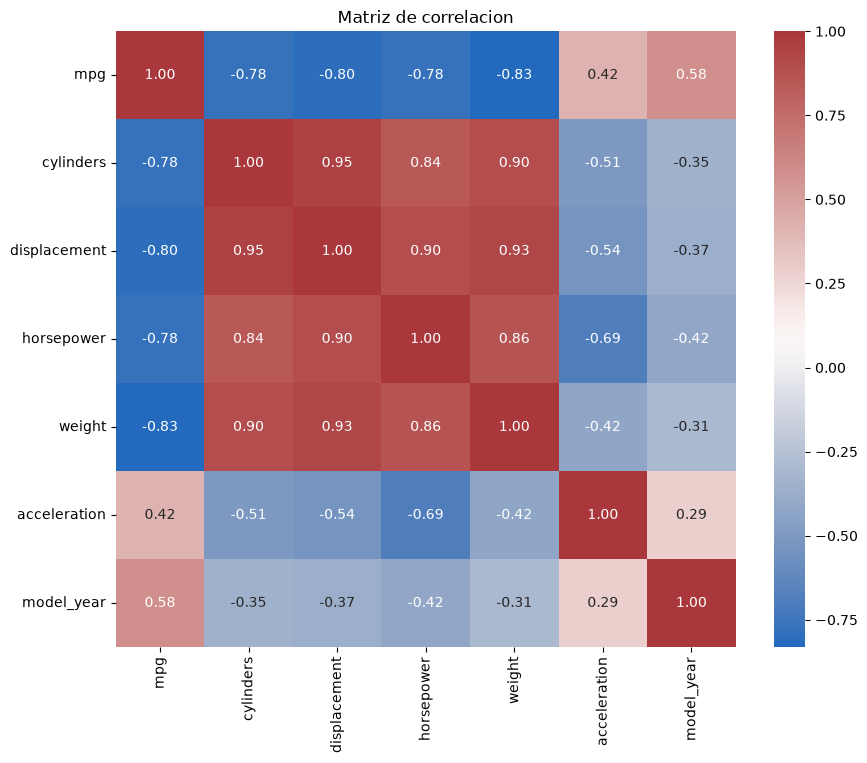


Tres variables con mayor asociación con MPG:
weight          0.831741
displacement    0.804203
horsepower      0.778427
Name: mpg, dtype: float64


In [64]:
# 14. Construye una matriz de correlación y heatmap de las variables numéricas. Identifica las
# tres variables con mayor asociación lineal absoluta con `mpg` y comenta posibles
# redundancias entre predictores.

columns_numericas = df.select_dtypes(include="number")
corr = columns_numericas.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag")
plt.title("Matriz de correlacion")
plt.show()

print("\nTres variables con mayor asociación con MPG:")
print(
    corr["mpg"]
    .drop("mpg")
    .abs()
    .sort_values(ascending=False)
    .head(3)
)

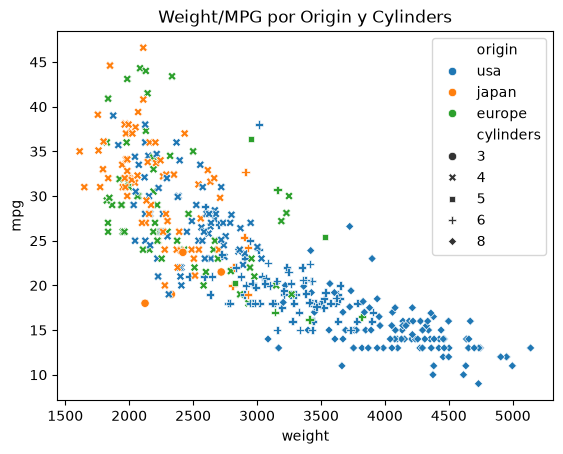

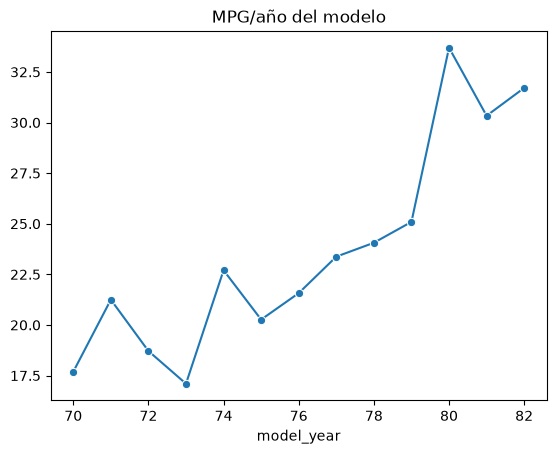

In [102]:
# 15. Realiza un análisis multivariado de `weight` frente a `mpg` incorporando `origin` y
# `cylinders` (mediante color, estilo, facetas u otra codificación). Añade la evolución media de
# `mpg` por `model_year`.

sns.scatterplot(
    data=df,
    x="weight",
    y="mpg",
    hue="origin",
    style="cylinders"
)

plt.title("Weight/MPG por Origin y Cylinders")
plt.show()

mpg_year = df.groupby("model_year")["mpg"].mean()

sns.lineplot(
    x=mpg_year.index,
    y=mpg_year.values,
    marker="o"
)

plt.title("MPG/año del modelo")
plt.show()



            count       mean  median
model_year                          
70             29  17.689655   16.00
71             28  21.250000   19.00
72             28  18.714286   18.50
73             40  17.100000   16.00
74             27  22.703704   24.00
75             30  20.266667   19.50
76             34  21.573529   21.00
77             28  23.375000   21.75
78             36  24.061111   20.70
79             29  25.093103   23.90
80             29  33.696552   32.70
81             29  30.334483   31.60
82             31  31.709677   32.00


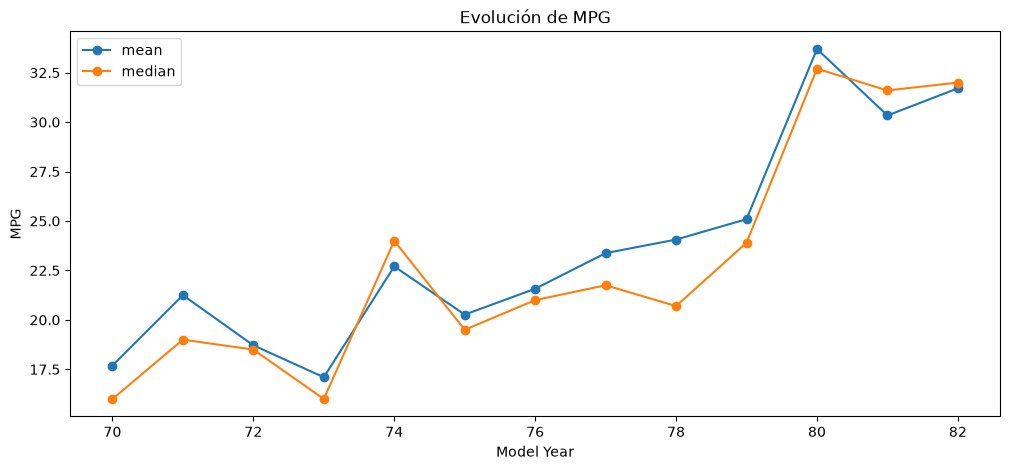

In [71]:
# 16. Analiza la evolución de `mpg` por `model_year`. Calcula media y mediana por año y
# represéntalas en una gráfica de líneas.

mpg_year = df.groupby("model_year")["mpg"].agg(
    count="count",
    mean="mean",
    median="median"
)

print(mpg_year)

mpg_year[["mean", "median"]].plot(
    marker="o",
    figsize=(12, 5)
)

plt.title("Evolución de MPG")
plt.xlabel("Model Year")
plt.ylabel("MPG")
plt.show()

        count         mean  median   min   max
origin                                        
europe     70  2423.300000  2240.0  1825  3820
japan      79  2221.227848  2155.0  1613  2930
usa       249  3361.931727  3365.0  1800  5140


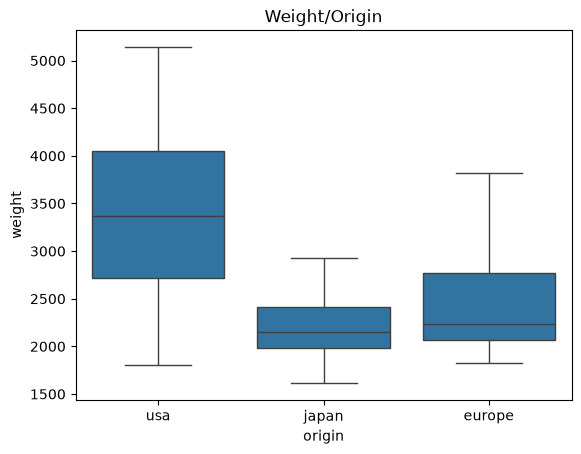

In [ ]:
# 17. Compara el `weight` de los automóviles por `origin` mediante estadísticas y boxplots.
# ¿Puede la diferencia de peso ayudar a explicar parte de las diferencias de `mpg` observadas
# entre orígenes?

weight_origin = df.groupby("origin")["weight"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
)

print(weight_origin)

sns.boxplot(
    data=df,
    x="origin",
    y="weight"
)

plt.title("Weight/Origin")
plt.show()

In [ ]:
# 18. Estudia el patrón de los valores faltantes de `horsepower`. Compara su frecuencia por
# `origin`, `cylinders` y `model_year`.
# Pista de trabajo: Con pocos casos faltantes conviene describir el patrón, pero evitar conclusiones fuertes.

df["hp_nulos"] = df["horsepower"].isna()

print("Por origen:")
print(pd.crosstab(df["origin"], df["hp_nulos"]))

print("\nPor cilindros:")
print(pd.crosstab(df["cylinders"], df["hp_nulos"]))

print("\nPor año del modelo:")
print(pd.crosstab(df["model_year"], df["hp_nulos"]))

Por origen:
hp_nulos  False  True 
origin                
europe       68      2
japan        79      0
usa         245      4

Por cilindros:
hp_nulos   False  True 
cylinders              
3              4      0
4            199      5
5              3      0
6             83      1
8            103      0

Por año del modelo:
hp_nulos    False  True 
model_year              
70             29      0
71             27      1
72             28      0
73             40      0
74             26      1
75             30      0
76             34      0
77             28      0
78             36      0
79             29      0
80             27      2
81             28      1
82             30      1


Correlación acceleration-mpg: 0.4202889121016507
Correlación weight-mpg: -0.8317409332443344
Correlación horsepower-mpg: -0.7784267838977762


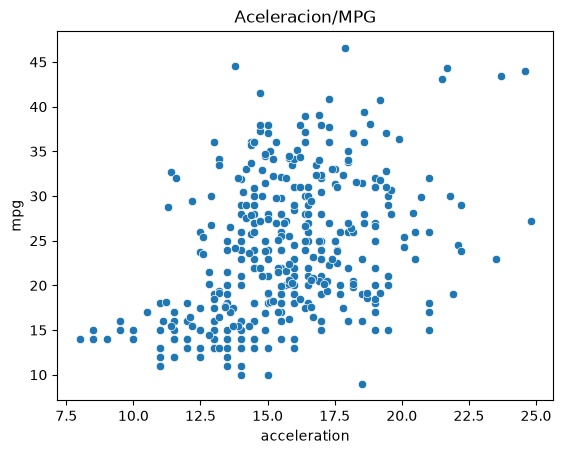

In [ ]:
# 19. Analiza la relación entre `acceleration` y `mpg` mediante scatterplot y correlación de
# Pearson. Compara su fuerza con las relaciones de `weight` y `horsepower` con `mpg`.

correlacion_acceleration_mpg = df[["acceleration", "mpg"]].corr().loc[
    "acceleration", "mpg"
]

print("Correlación acceleration-mpg:", correlacion_acceleration_mpg)
print("Correlación weight-mpg:", correlacion_weight_mpg)
print("Correlación horsepower-mpg:", correlacion_hp_mpg)

sns.scatterplot(
    data=df,
    x="acceleration",
    y="mpg"
)

plt.title("Aceleracion/MPG")
plt.show()

              displacement  horsepower  weight
displacement         1.000       0.897   0.933
horsepower           0.897       1.000   0.865
weight               0.933       0.865   1.000


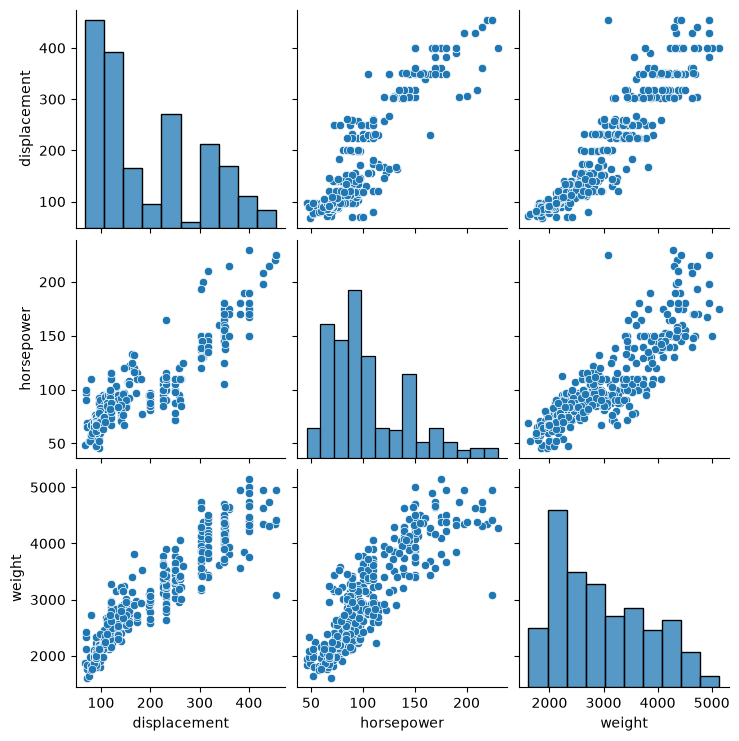

In [ ]:
# 20. Explora las relaciones entre `displacement`, `horsepower` y `weight`. Calcula sus
# correlaciones y crea gráficos de dispersión. ¿Qué problema podría aparecer si se usan
# simultáneamente como predictores sin revisar redundancias?

variables = [
    "displacement",
    "horsepower",
    "weight"
]

corr_motor = df[variables].corr()

print(corr_motor.round(3))

sns.pairplot(
    df[variables].dropna()
)

plt.show()

In [83]:
# 21. Construye una tabla pivote con el `mpg` medio por `cylinders` y `origin`, incluyendo el
# número de automóviles por grupo. ¿El patrón de cilindros se mantiene dentro de cada origen?
# Señala grupos con muestras pequeñas.

tabla_mpg = pd.pivot_table(
    df,
    values="mpg",
    index="cylinders",
    columns="origin",
    aggfunc="mean"
)

tabla_n = pd.pivot_table(
    df,
    values="mpg",
    index="cylinders",
    columns="origin",
    aggfunc="count"
)

print("MPG medio:")
print(tabla_mpg.round(2))

print("\nNúmero de automóviles:")
print(tabla_n)

MPG medio:
origin     europe  japan    usa
cylinders                      
3             NaN  20.55    NaN
4           28.41  31.60  27.84
5           27.37    NaN    NaN
6           20.10  23.88  19.66
8             NaN    NaN  14.96

Número de automóviles:
origin     europe  japan    usa
cylinders                      
3             NaN    4.0    NaN
4            63.0   69.0   72.0
5             3.0    NaN    NaN
6             4.0    6.0   74.0
8             NaN    NaN  103.0


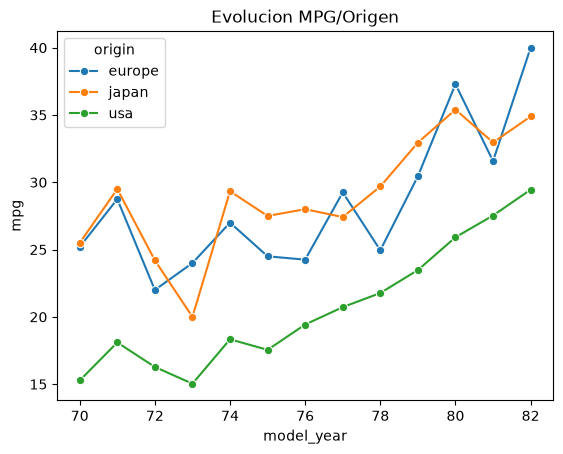

In [86]:
# 22. Compara la evolución temporal de `mpg` entre `origin` usando líneas por grupo. ¿Los tres
# orígenes mejoran con el tiempo? ¿La brecha entre orígenes permanece constante?

mpg_año_origen = (
    df.groupby(["model_year", "origin"])["mpg"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=mpg_año_origen,
    x="model_year",
    y="mpg",
    hue="origin",
    marker="o"
)

plt.title("Evolucion MPG/Origen")
plt.show()

In [ ]:
# 23. Compara los outliers de `horsepower` detectados mediante 1.5·IQR y mediante |z| > 3.
# Lista los vehículos más extremos y explica por qué un método puede ser más estricto que el
# otro en una distribución asimétrica.

hp_df = df.dropna(subset=["horsepower"]).copy()

media = hp_df["horsepower"].mean()
std = hp_df["horsepower"].std()

hp_df["z"] = (
    hp_df["horsepower"] - media
) / std

outliers_iqr = hp_df[
    (hp_df["horsepower"] < limite_inferior) |
    (hp_df["horsepower"] > limite_superior)
]

outliers_z = hp_df[
    hp_df["z"].abs() > 3
]

print("Outliers IQR:", len(outliers_iqr))
print("Outliers Z > 3:", len(outliers_z))

print("\nIQR:")
print(
    outliers_iqr[
        ["horsepower", "name"]
    ].sort_values("horsepower", ascending=False)
)

print("\nZ > 3:")
print(
    outliers_z[
        ["horsepower", "z", "name"]
    ].sort_values("horsepower", ascending=False)
)

print("\nIntersección:")
print(
    set(outliers_iqr.index).intersection(
        set(outliers_z.index)
    )
)

Outliers IQR: 10
Outliers Z > 3: 5

IQR:
     horsepower                          name
116       230.0            pontiac grand prix
8         225.0              pontiac catalina
95        225.0      buick electra 225 custom
13        225.0       buick estate wagon (sw)
6         220.0              chevrolet impala
7         215.0             plymouth fury iii
94        215.0  chrysler new yorker brougham
25        215.0                     ford f250
27        210.0                    dodge d200
67        208.0               mercury marquis

Z > 3:
     horsepower         z                      name
116       230.0  3.261284        pontiac grand prix
13        225.0  3.131384   buick estate wagon (sw)
8         225.0  3.131384          pontiac catalina
95        225.0  3.131384  buick electra 225 custom
6         220.0  3.001484          chevrolet impala

Intersección:
{6, 8, 13, 116, 95}


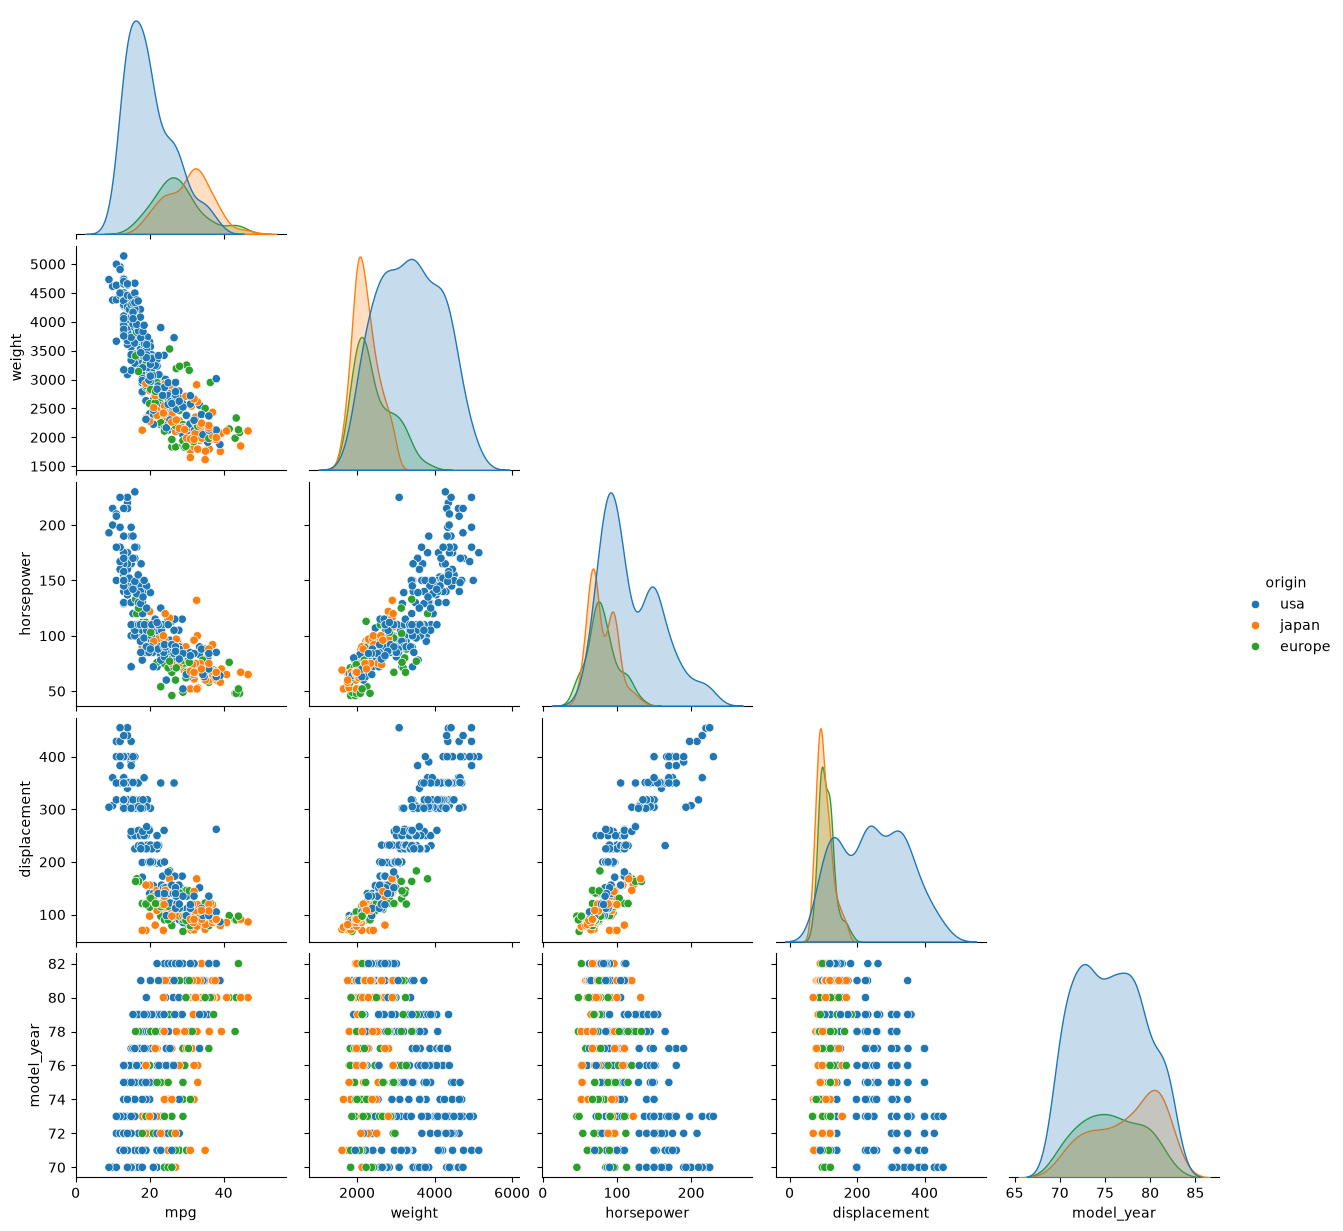

In [88]:
# 24. Construye un `pairplot` con `mpg`, `weight`, `horsepower`, `displacement` y
# `model_year`, usando `origin` como color.

variables = [
    "mpg",
    "weight",
    "horsepower",
    "displacement",
    "model_year"
]

sns.pairplot(
    df[variables + ["origin"]].dropna(),
    hue="origin",
    corner=True
)

plt.show()


In [ ]:
# 25. Elabora un “registro de decisiones” para preparar un análisis posterior: decide qué harías
# con los nulos de `horsepower`, `name`, `origin`, los outliers de potencia y las variables
# altamente correlacionadas.

df.info


<bound method DataFrame.info of       mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  hp_missing  hp_nulos  
0            70     usa  che